# Geodesic Demo

First, we import the necessary modules.

In [1]:
%load_ext autoreload
%autoreload 2

from jax.config import config
config.update("jax_enable_x64", True)

from fadge import GRRT
from jax   import numpy as np

from matplotlib import pyplot as plt
from itertools  import product

We then instasize `PRay` into an object

In [2]:
grrt = GRRT(
    aspin=1.41421356, ind='time',
    eps=-1e-3, atol=1e-6, rtol=0, hmin=0,
    names={'ind':'t'},
    dtype=np.float64,
)

grrt.set_cam(1e4, 60, 0)
#grrt.set_image(4, 64, alpha0=2, beta0=2)
grrt.set_image(16, 128)

/Users/ckc/Library/Python/3.10/lib/python/site-packages/jax/experimental/maps.py:497: UserWarning: xmap is an experimental feature and probably has bugs!
  warn("xmap is an experimental feature and probably has bugs!")


There is no event horizon


To setup the initial conditions, we first set the camera location, and then specify the image.

To performm geodesic integration, simply call `pray.geode()`.
When no argument is specified, the integration is carried out to `-2 * r_obs`.
The return values are the full steps during the integration.

In [3]:
l, f = grrt.geode() # full step output

i,j = 0,slice(None)

ft = f[:,0,0,i,j]
fx = f[:,0,1,i,j]
fy = f[:,0,2,i,j]
fz = f[:,0,3,i,j]

jit(masked_do); input: Traced<ShapedArray(float64[])>with<DynamicJaxprTrace(level=0/1)> Traced<ShapedArray(float64[2,4,128,128])>with<DynamicJaxprTrace(level=0/1)> Traced<ShapedArray(float64[])>with<DynamicJaxprTrace(level=0/1)> [Traced<ShapedArray(float64[2,4,128,128])>with<DynamicJaxprTrace(level=0/1)>, Traced<ShapedArray(float64[2,4,128,128])>with<DynamicJaxprTrace(level=0/1)>, Traced<ShapedArray(float64[2,4,128,128])>with<DynamicJaxprTrace(level=0/1)>, Traced<ShapedArray(float64[2,4,128,128])>with<DynamicJaxprTrace(level=0/1)>, Traced<ShapedArray(float64[2,4,128,128])>with<DynamicJaxprTrace(level=0/1)>, Traced<ShapedArray(float64[2,4,128,128])>with<DynamicJaxprTrace(level=0/1)>, Traced<ShapedArray(float64[2,4,128,128])>with<DynamicJaxprTrace(level=0/1)>]


100%|██████████████████████████████████████████████████████████████| 100/100 [07:11<00:00,  4.69s/it, t=-2.22e+04, dt=-6.21e+03]


target = -20000.0 exceeded; SKIP


Because `PRay` uses `XAJ` for solving ODEs, it supports dense output.
We can put a lot of sampling points near the black hole for better visualization of the geodeiscs.

We are finally ready to plot the results.

Text(0, 0.5, 'y')

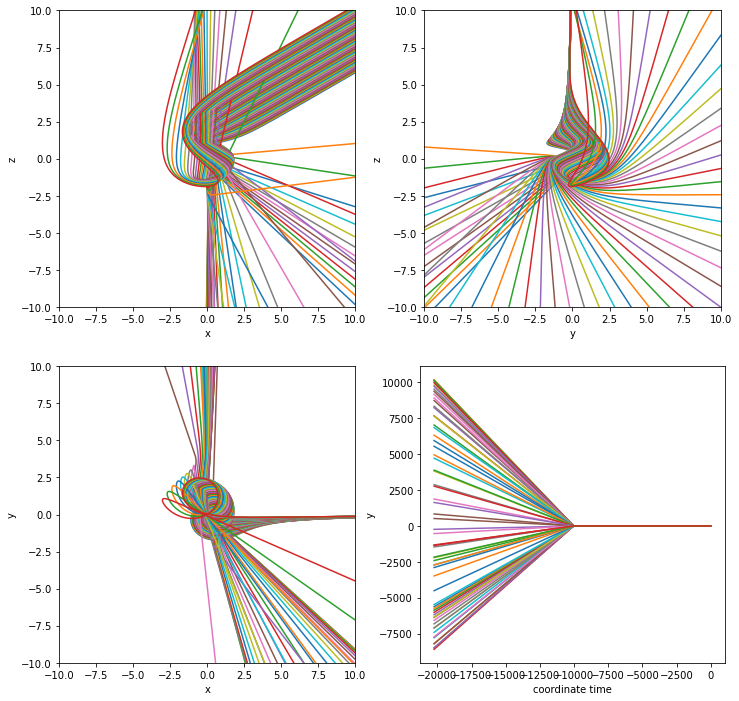

In [13]:
fig, axes = plt.subplots(2,2, figsize=(12,12))#, sharey=True)

lim = 10

axes[0][0].plot(fx, fz)
axes[0][1].plot(fy, fz)
axes[1][0].plot(fx, fy)
axes[1][1].plot(ft, fy)

#fig.tight_layout()

ax = axes[0][0]
ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_xlim(-lim,lim)
ax.set_ylim(-lim,lim)
ax.set_aspect('equal')

ax = axes[0][1]
ax.set_xlabel('y')
ax.set_ylabel('z')
ax.set_xlim(-lim,lim)
ax.set_ylim(-lim,lim)
ax.set_aspect('equal')

ax = axes[1][0]
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(-lim,lim)
ax.set_ylim(-lim,lim)
ax.set_aspect('equal')

ax = axes[1][1]
ax.set_xlabel('coordinate time')
ax.set_ylabel('y')

Text(0, 0.5, 'y')

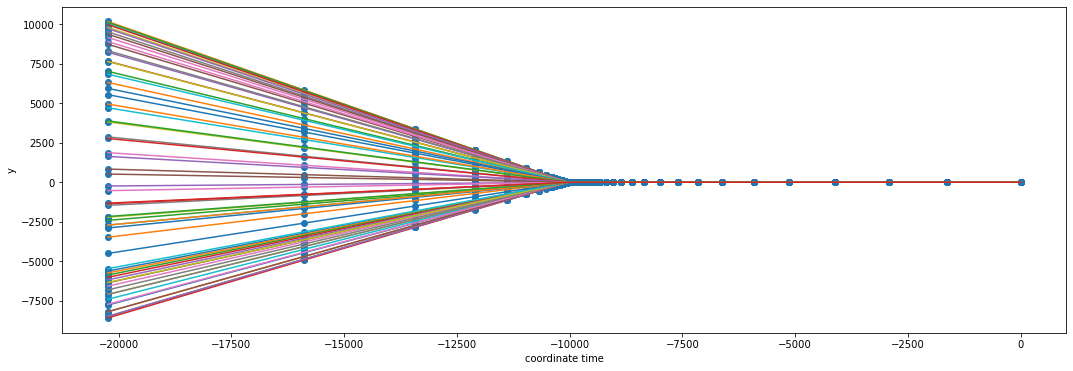

In [14]:
fig, ax = plt.subplots(1,1, figsize=(18,6))
ax.plot(ft, fy)
ax.scatter(ft, fy)
ax.set_xlabel('coordinate time')
ax.set_ylabel('y')

ValueError: x and y must be the same size

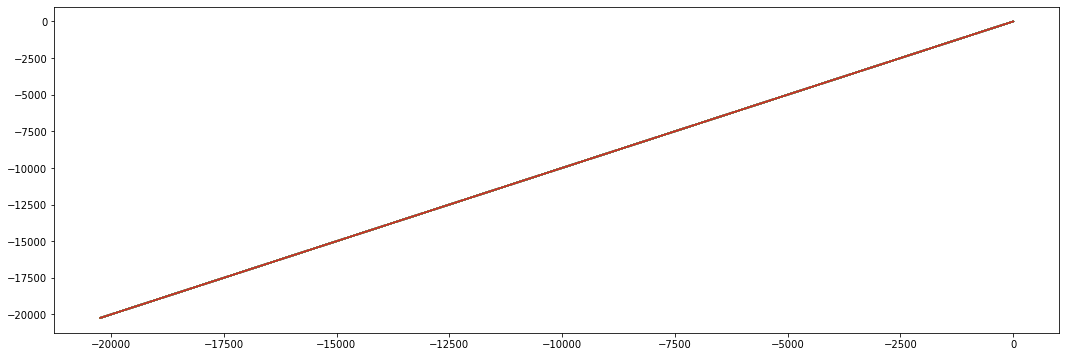

In [15]:
fig, ax = plt.subplots(1,1, figsize=(18,6))
ax.plot(l, ft)
ax.scatter(l[::2], ft[::2])
ax.set_xlabel('affine parameter')
ax.set_ylabel('coordinate time')

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(18,6))
ax.plot(abs(l), abs(ft))
ax.scatter(abs(l[::2]), abs(ft[::2]))
ax.set_xlabel('|affine parameter|')
ax.set_ylabel('|coordinate time|')